Introduction to Neural Networks

In [1]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader, random_split

import seaborn as sns

# MNIST dataset

In [2]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('./data/mnist')

Establecemos los datos de prueba, validacion y entrenamiento. Tambien nos saltamos los 8 bytes de cabecera de los archivos "me imagino que es porque no los necesitamos"
Al final ajustamos el tamaño de las imagenes a 28x28, esto a las 60,000 imagenes.

In [4]:
x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)

Convertimos las imagenes a vectores de 784 pixeles a flotantes y las etiquetas a columnas tipo int

In [ ]:
class MNISTDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y.squeeze(), dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

#Generamos datasets
train_dataset = MNISTDataset(x_train, y_train)  # 50,000
val_dataset   = MNISTDataset(x_val, y_val)       # 10,000
test_dataset  = MNISTDataset(x_test, y_test)     # 10,000

#Dividir en mini-batches automáticamente
#Mezclar los datos en cada época (shuffle)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)


Necesitas crear una clase que herede de Dataset, para poder utilizar pytorch    

In [10]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

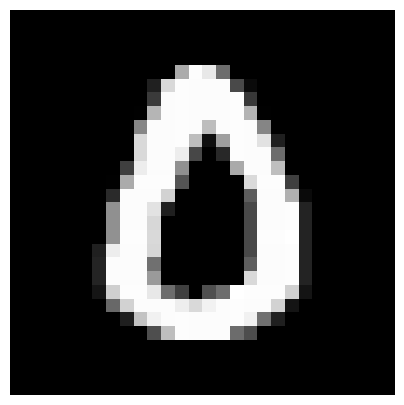

'Label: 0'

In [11]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

# Defining the Neural Network

In [26]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 200),
            nn.ReLU(),
            nn.Linear(200, 10)
        )

    def forward(self, x):
        return self.net(x)

model = NeuralNetwork()



No hace falta definir backward ni update, ya que PyTorch lo hace por nosotros.

Training the Neural Network

In [27]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # Función de pérdida para clasificación multiclase
optimizer = optim.Adam(model.parameters(), lr=0.001) # lr (learning rate) controla el tamaño de cada actualización


In [16]:
def scale(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

x_mean = x_train.mean()
x_std = x_train.std()

x_train = scale(x_mean, x_std, x_train)
x_val = scale(x_mean, x_std, x_val)
x_test = scale(x_mean, x_std, x_test)

In [17]:
def create_minibatches(batch_size, x, y, shuffle = False):
    total_data = x.shape[0]
    if shuffle:
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
    return ((x[i:i + batch_size], y[i:i + batch_size]) for i in range(0, total_data, batch_size))

In [18]:
def softmaxXEntropy(x, y):
    batch_size = x.shape[1]
    exp_scores = np.exp(x)
    probs = exp_scores / exp_scores.sum(axis = 0)

    # Cost
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    cost = np.sum(-np.log(y_hat)) / batch_size

    # Gradients
    # For a softmax layer, the gradient is just the predicted probabilities minus the one-hot encoded true labels.
    probs[y.squeeze(), np.arange(batch_size)] -= 1
    x.grad = probs.copy()

    return cost

In [19]:
def accuracy(x, y):
    pred = model.forward(x.T.view(Tensor))
    correct = np.sum(np.argmax(pred, axis=0) == y.squeeze())
    total = pred.shape[1]
    return correct/total

In [20]:
def train(model, epochs, batch_size=128, learning_rate=1e-3):
    for epoch in range(epochs):
        epoch_iterator = tqdm(
            enumerate(create_minibatches(batch_size, x_train, y_train)),
            total=len(x_train) // batch_size,
            desc=f"Epoch {epoch+1}/{epochs}",
            leave=True
        )

        for i, (x, y) in epoch_iterator:
            scores = model.forward(x.T.view(Tensor))
            cost = softmaxXEntropy(scores, y)
            model.backward()
            model.update(learning_rate)

            epoch_iterator.set_postfix(cost=f"{cost:.4f}")

        val_acc = accuracy(x_val, y_val)
        print(f"Cost: {cost:.4f}, Val Accuracy: {val_acc:.4f}")

In [21]:
model = NeuralNetwork([
    LinearLayer(784, 200),
    ReLU(),
    LinearLayer(200, 10)])

TypeError: NeuralNetwork.__init__() takes 1 positional argument but 2 were given

In [ ]:
print(f"accuracy before training: {accuracy(x_val, y_val)}")

accuracy before training: 0.1353


In [ ]:
mb_size = 256
learning_rate = 0.0001
epochs = 20
train(model, epochs, mb_size, learning_rate)

Epoch 1/20: 196it [00:01, 140.91it/s, cost=0.4265]                         


Cost: 0.4265, Val Accuracy: 0.9115


Epoch 2/20: 196it [00:01, 141.62it/s, cost=0.3198]                         


Cost: 0.3198, Val Accuracy: 0.9295


Epoch 3/20: 196it [00:01, 159.47it/s, cost=0.2621]                         


...

Cost: 0.0653, Val Accuracy: 0.9697


Epoch 19/20: 196it [00:01, 169.14it/s, cost=0.0616]                         


Cost: 0.0616, Val Accuracy: 0.9700


Epoch 20/20: 196it [00:01, 166.71it/s, cost=0.0584]                         


Cost: 0.0584, Val Accuracy: 0.9702


Testing the model

In [ ]:
print(f'Test accuracy: {accuracy(x_test, y_test)}')

Test accuracy: 0.9673


Text(0.5, 1.0, 'Confusion Matrix')

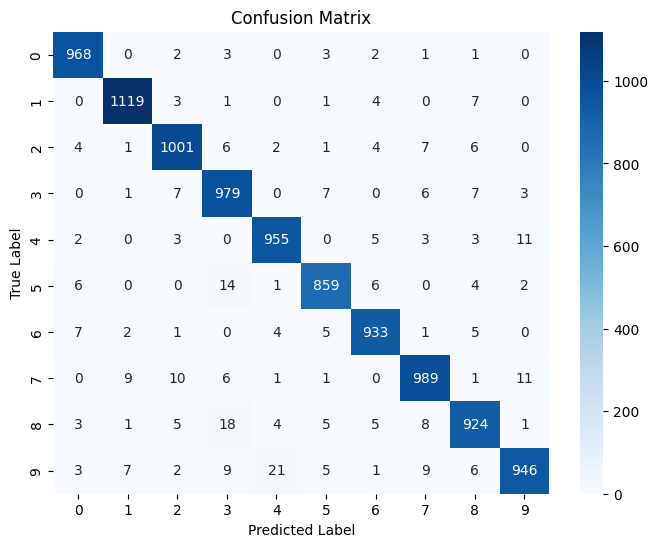

In [ ]:
test_scores = model.forward(x_test.T.view(Tensor))
y_pred = np.argmax(test_scores, axis=0)
conf_matrix = np.zeros((10, 10), dtype=int)

for true_label, pred_label in zip(y_test.squeeze(), y_pred.squeeze()):
    conf_matrix[true_label, pred_label] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

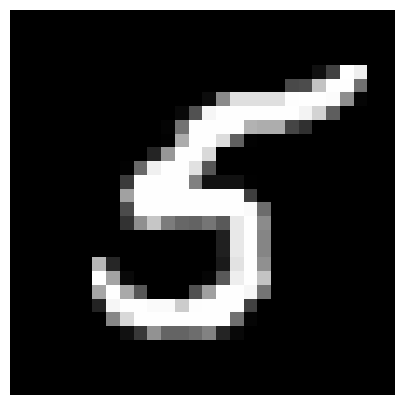

'Label: 5'

'Predicted: 5'

In [ ]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {y_pred[random_idx]}")